# 02 — Recode and the missingness map

We turn the raw file into the analysis sample and keep **Refused** and **Don't
know** as *distinct* income categories — the entire study turns on not merging them.
A row is kept when the outcome (FMD) and all covariates are present and income is a
bracket, a Don't-know, or a Refusal; income "not asked" (blank) is dropped.

All recoding lives in `recode.py` (verified against the codebook in notebook 01).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import recode as rc

DATA = os.path.abspath(os.path.join('..', 'data'))
DERIVED = os.path.join(DATA, 'derived')
df = pd.read_parquet(os.path.join(DERIVED, 'brfss_2023_raw_subset.parquet'))

rec, info = rc.make_recoded(df)
aux = info['aux']
n = info['n_kept']
print(f"raw rows:            {info['n_raw']:>8,}")
print(f"income 'not asked':  {info['dropped_income_blank']:>8,}  (dropped)")
print(f"analysis rows kept:  {n:>8,}")
print(f"  bracketed income:  {info['n_bracket']:>8,}  ({100*info['n_bracket']/n:.1f}%)")
print(f"  don't know (77):   {info['n_dk']:>8,}  ({100*info['n_dk']/n:.1f}%)")
print(f"  refused (99):      {info['n_refused']:>8,}  ({100*info['n_refused']/n:.1f}%)")
print(f"design columns ({len(info['colnames'])}): {info['colnames']}")

raw rows:             433,323
income 'not asked':     8,075  (dropped)
analysis rows kept:   408,944
  bracketed income:   338,056  (82.7%)
  don't know (77):     33,430  (8.2%)
  refused (99):        37,458  (9.2%)
design columns (20): ['intercept', 'age_z', 'age_z2', 'female', 'race_Black_NH', 'race_Asian_NH', 'race_AIAN_NH', 'race_Hispanic', 'race_Other_NH', 'educ_LtHS', 'educ_HSgrad', 'educ_SomeColl', 'employ_Unemployed', 'employ_Homemaker_Student', 'employ_Retired', 'employ_Unable', 'marital_Div_Sep', 'marital_Widowed', 'marital_NeverMarried', 'marital_UnmarriedCouple']


## The crude income–FMD gradient (weighted), by bracket

Before any modeling, the survey-weighted prevalence of frequent mental distress by
income bracket shows the gradient we will quantify. Error bars are design-naive here
(±1.96·SE of a weighted proportion) — the design-based inference comes later.

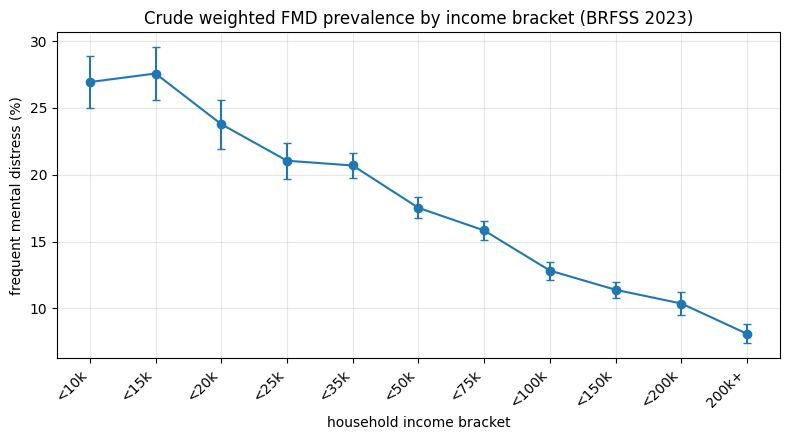

,code,bracket,fmd_pct,ci95,n
0,1,<10k,26.936718,1.929930,8778
1,2,<15k,27.576729,1.972042,9402
2,3,<20k,23.786746,1.838975,12284
3,4,<25k,21.048916,1.329020,17437
4,5,<35k,20.694786,0.907807,37162
5,6,<50k,17.524624,0.789282,46184
6,7,<75k,15.829356,0.698436,56590
7,8,<100k,12.827896,0.680457,48257
8,9,<150k,11.391599,0.610091,51529
9,10,<200k,10.363779,0.881167,24036


In [2]:
def wmean_se(y, w):
    # weighted proportion and its design-naive SE using the effective sample size
    # n_eff = (sum w)^2 / sum w^2 :  SE = sqrt(p(1-p)/n_eff)
    m = np.average(y, weights=w)
    n_eff = w.sum() ** 2 / (w ** 2).sum()
    return m, np.sqrt(m * (1 - m) / n_eff)

br = aux[aux['kind'] == 'bracket'].copy()
# recover bracket code from the log-lower bound for ordering
codes = []
log_lo = rec.log_lo[rec.kind == 'bracket']
lows = {code: (np.log(lo) if lo > 0 else -np.inf)
        for code, (lo, hi) in rc.INCOME_BRACKETS_USD.items()}
inv = {round(v, 6): code for code, v in lows.items()}
br_code = np.array([inv.get(round(v, 6), np.nan) for v in log_lo])
br['code'] = br_code

rows = []
for code, (lo, hi) in rc.INCOME_BRACKETS_USD.items():
    sub = br[br['code'] == code]
    if len(sub) == 0:
        continue
    m, se = wmean_se(sub['outcome'].to_numpy(), sub['w'].to_numpy())
    label = f"<{hi/1000:.0f}k" if np.isfinite(hi) else "200k+"
    rows.append((code, label, 100 * m, 100 * 1.96 * se, len(sub)))
grad = pd.DataFrame(rows, columns=['code', 'bracket', 'fmd_pct', 'ci95', 'n'])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(grad['code'], grad['fmd_pct'], yerr=grad['ci95'], marker='o',
            capsize=3, lw=1.5)
ax.set_xticks(grad['code']); ax.set_xticklabels(grad['bracket'], rotation=45, ha='right')
ax.set_xlabel('household income bracket'); ax.set_ylabel('frequent mental distress (%)')
ax.set_title('Crude weighted FMD prevalence by income bracket (BRFSS 2023)')
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
grad

## Who is missing income — and is it the high earners who refuse?

We cannot see refusers' income, so we test the conventional "high-income people
refuse" assumption through observable correlates of income: **education**,
**employment**, **age**, and **race/ethnicity**. For each group we plot the weighted
share who **refused** vs the share who said **don't know**. If refusal rose with
income proxies (e.g. with education/employment) while don't-know did not, that would
support the high-income-refuser story; the opposite pattern would echo the MIHA
finding that the most vulnerable are missing.

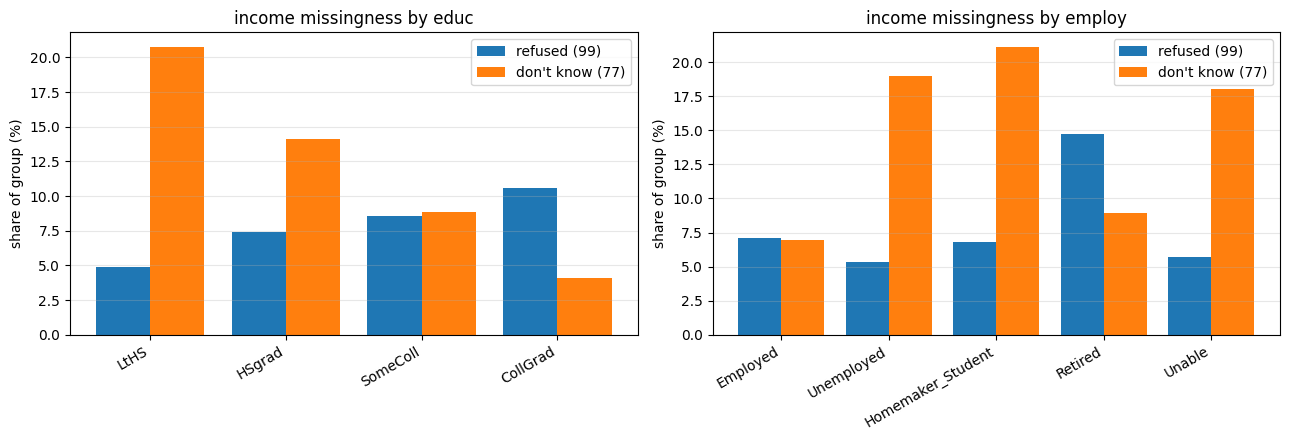

In [3]:
def shares_by(col, order=None):
    g = aux.groupby(col)
    out = {}
    for key, sub in g:
        w = sub['w'].to_numpy()
        tot = w.sum()
        out[key] = {
            'refused': 100 * w[sub['kind'].to_numpy() == 'refused'].sum() / tot,
            'dk':      100 * w[sub['kind'].to_numpy() == 'dk'].sum() / tot,
            'n': len(sub),
        }
    res = pd.DataFrame(out).T
    if order:
        res = res.reindex([o for o in order if o in res.index])
    return res

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
educ_order = ['LtHS', 'HSgrad', 'SomeColl', 'CollGrad']
emp_order = ['Employed', 'Unemployed', 'Homemaker_Student', 'Retired', 'Unable']
for ax, col, order in [(axes[0], 'educ', educ_order), (axes[1], 'employ', emp_order)]:
    s = shares_by(col, order)
    x = np.arange(len(s))
    ax.bar(x - 0.2, s['refused'], 0.4, label='refused (99)')
    ax.bar(x + 0.2, s['dk'], 0.4, label='don\'t know (77)')
    ax.set_xticks(x); ax.set_xticklabels(s.index, rotation=30, ha='right')
    ax.set_ylabel('share of group (%)'); ax.set_title(f'income missingness by {col}')
    ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

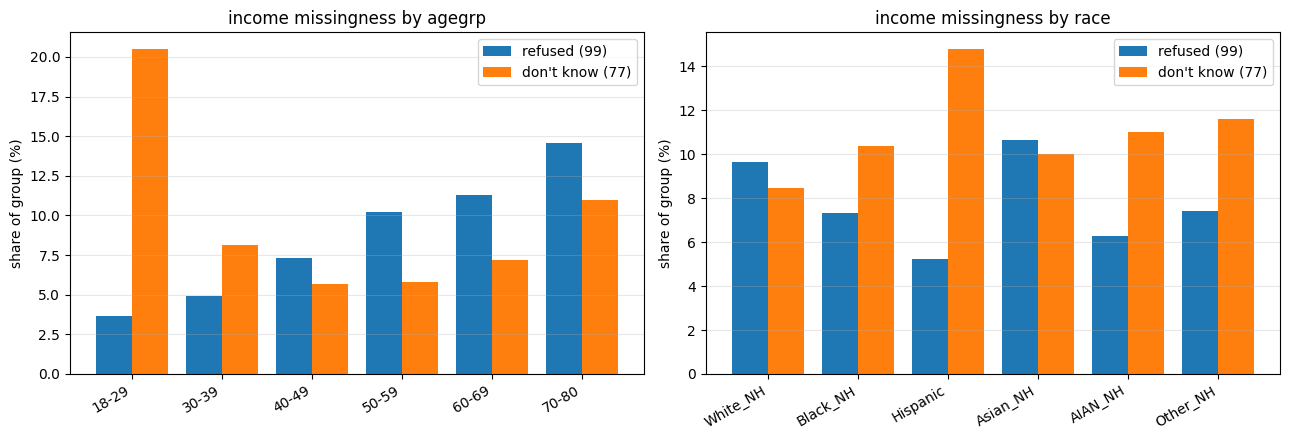

In [4]:
# age and race views
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
aux2 = aux.copy()
aux2['agegrp'] = pd.cut(aux2['age'], [17, 29, 39, 49, 59, 69, 80],
                        labels=['18-29', '30-39', '40-49', '50-59', '60-69', '70-80'])
for ax, col, order in [(axes[0], 'agegrp', None),
                       (axes[1], 'race', ['White_NH', 'Black_NH', 'Hispanic',
                                          'Asian_NH', 'AIAN_NH', 'Other_NH'])]:
    g = aux2.groupby(col, observed=True)
    refused, dk, labels = [], [], []
    keys = order if order else list(g.groups.keys())
    for key in keys:
        if key not in g.groups:
            continue
        sub = aux2.loc[g.groups[key]]
        w = sub['w'].to_numpy(); tot = w.sum()
        refused.append(100 * w[sub['kind'].to_numpy() == 'refused'].sum() / tot)
        dk.append(100 * w[sub['kind'].to_numpy() == 'dk'].sum() / tot)
        labels.append(str(key))
    x = np.arange(len(labels))
    ax.bar(x - 0.2, refused, 0.4, label='refused (99)')
    ax.bar(x + 0.2, dk, 0.4, label="don't know (77)")
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha='right')
    ax.set_ylabel('share of group (%)'); ax.set_title(f'income missingness by {col}')
    ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

**Reading the panels.** Refused and don't-know trace clearly *different*
demographic patterns — the empirical signature that they are distinct mechanisms,
not one lumped "missing." That is exactly what the published collapsed code hides
and what models B and C will treat separately.

## Save the analysis sample

We persist the flattened analysis sample (design matrix + outcome + weights +
missingness label + bracket bounds + stratum) so the modeling notebooks load in
seconds and reproduce exactly what was recoded here.

In [5]:
frame = rc.recoded_to_frame(rec, info['colnames'], info['strata'])
out = os.path.join(DERIVED, 'brfss_2023_analysis.parquet')
frame.to_parquet(out, index=False)
print('wrote', out, f"({os.path.getsize(out)/1e6:.1f} MB); shape {frame.shape}")
frame.head(3)

wrote /mnt/share/homes/abie/projects/2026/ai_assisted_us_health_data_analysis/data/derived/brfss_2023_analysis.parquet (5.4 MB); shape (408944, 27)


,X__intercept,X__age_z,X__age_z2,X__female,X__race_Black_NH,X__race_Asian_NH,X__race_AIAN_NH,X__race_Hispanic,X__race_Other_NH,X__educ_LtHS,...,X__marital_Widowed,X__marital_NeverMarried,X__marital_UnmarriedCouple,y,w,kind,log_lo,log_hi,log_mid,strata
0,1.0,1.370111,1.877204,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.043586,refused,NaN,NaN,NaN,11011.0
1,1.0,1.370111,1.877204,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.933998,refused,NaN,NaN,NaN,11012.0
2,1.0,1.370111,1.877204,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.035891,bracket,9.21034,9.615805,9.433484,11011.0
